# Consistency check: MCEvidence, LHME (harmonic) vs. Nautilus

MCMC chains in `../nautilus/` use the same sampled parameters and priors as the Nautilus nested-sampling runs (DES likelihood), for two data combinations:

- **DD** (`sn.desdovekie`)
- **DD+BAO** (`sn.desdovekie + bao.desi_dr2`)

Sampled parameters:
- $\Lambda$CDM: `h`, `Omega_m`
- CPL: `h`, `Omega_m`, `w0_fld`, `wa_fld`

There are 8 MCMC chains per run, so we test harmonic with `block_num = 8, 16, 32` (no further splitting, 2x, 4x).

Nautilus reference values (paper):
- DD: $\ln\mathcal{Z}_{\Lambda\mathrm{CDM}} = -822.5$, $\ln\mathcal{Z}_{\mathrm{CPL}} = -823.4$
- DD+BAO: $\ln\mathcal{Z}_{\Lambda\mathrm{CDM}} = -833.2$, $\ln\mathcal{Z}_{\mathrm{CPL}} = -834.3$

In [1]:
from cosmctools import *
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 300
mpl.rc("axes", labelsize=16)
mpl.rc("legend", fontsize=14)
mpl.rc("xtick", labelsize=12)
mpl.rc("ytick", labelsize=12)

In [2]:
def make_and_train(root, params, burnin, block_num, temp=0.8, nchains=8):
    m = cosmo_model(root, burnin=burnin, block_num=block_num, nchains=nchains)
    m.set_sampled_params(params)
    m.train_model(verbose=False, store_model=False)
    m.set_temp(temp=temp)
    return m


# Nautilus reference values (paper)
NAUT_DD = {"lcdm": -822.5, "cpl": -823.4}
NAUT_DD["bf"] = NAUT_DD["cpl"] - NAUT_DD["lcdm"]

NAUT_DDBAO = {"lcdm": -833.2, "cpl": -834.3}
NAUT_DDBAO["bf"] = NAUT_DDBAO["cpl"] - NAUT_DDBAO["lcdm"]

block_nums = [8, 16, 24]
block_offsets = {8: -0.18, 16: 0.0, 24: 0.18}
block_colors = {8: "tab:cyan", 16: "blue", 24: "navy"}

# DD

In [3]:
## parameters (nautilus runs)
lcdm_params_dd = ["h", "Omega_m"]
cpl_params_dd = ["h", "Omega_m", "w0_fld", "wa_fld"]

lcdm_root_dd = "../nautilus/lcdm_DD"
cpl_root_dd = "../nautilus/cpl_DD"

## initialising objects (8 chains, default block_num=16)
lcdm_dd = cosmo_model(lcdm_root_dd, block_num=16, nchains=8, burnin=0.3)
cpl_dd = cosmo_model(cpl_root_dd, block_num=16, nchains=8, burnin=0.3)

lcdm_dd.set_sampled_params(lcdm_params_dd)
cpl_dd.set_sampled_params(cpl_params_dd)

print(f"LCDM (DD) R-1 = {lcdm_dd.get_gelman_rubin()}")
print(f"CPL  (DD) R-1 = {cpl_dd.get_gelman_rubin()}")

../nautilus/lcdm_DD.1.txt
../nautilus/lcdm_DD.2.txt
../nautilus/lcdm_DD.3.txt
../nautilus/lcdm_DD.4.txt
../nautilus/lcdm_DD.5.txt
../nautilus/lcdm_DD.6.txt
../nautilus/lcdm_DD.7.txt
../nautilus/lcdm_DD.8.txt
Removed 0.3 as burn in
LCDM (DD) R-1 = 0.004409570708647339
../nautilus/cpl_DD.1.txt
../nautilus/cpl_DD.2.txt
../nautilus/cpl_DD.3.txt
../nautilus/cpl_DD.4.txt
../nautilus/cpl_DD.5.txt
../nautilus/cpl_DD.6.txt
../nautilus/cpl_DD.7.txt
../nautilus/cpl_DD.8.txt
Removed 0.3 as burn in
CPL  (DD) R-1 = 0.00791403478297603


In [4]:
# train normalising flows
# lcdm_dd.train_model(verbose=True, temp=0.8)
# cpl_dd.train_model(verbose=True, temp=0.8)

In [5]:
# MCEvidence Bayes factor (DD)
mce_dd_lcdm = lcdm_dd.mcevidence
mce_dd_cpl = cpl_dd.mcevidence
mce_dd = lcdm_dd.get_MCE_bayes_factor(cpl_dd)

INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../nautilus/lcdm_DD_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.144
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=2
INFO:MCEvidence.py.setup():164      Loading chain from ../nautilus/lcdm_DD_BE
INFO:MCEvidence.py.load_from_file():666       loading files: ../nautilus/lcdm_DD_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.1.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.5.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.4.txt
INFO:MCEvidence.py

RUNNING MCMC EVIDENCE FOR COBAYA
../nautilus/lcdm_DD.1.txt
../nautilus/lcdm_DD.2.txt
../nautilus/lcdm_DD.3.txt
../nautilus/lcdm_DD.4.txt
../nautilus/lcdm_DD.5.txt
../nautilus/lcdm_DD.6.txt
../nautilus/lcdm_DD.7.txt
../nautilus/lcdm_DD.8.txt
Removed no burn in
ln(B)[k=1] = -817.8198285152376


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../nautilus/cpl_DD_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=1.872
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=4
INFO:MCEvidence.py.setup():164      Loading chain from ../nautilus/cpl_DD_BE
INFO:MCEvidence.py.load_from_file():666       loading files: ../nautilus/cpl_DD_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.5.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.1.txt
INFO:MCEvidence.py.removeB

../nautilus/cpl_DD.1.txt
../nautilus/cpl_DD.2.txt
../nautilus/cpl_DD.3.txt
../nautilus/cpl_DD.4.txt
../nautilus/cpl_DD.5.txt
../nautilus/cpl_DD.6.txt
../nautilus/cpl_DD.7.txt
../nautilus/cpl_DD.8.txt
Removed no burn in
ln(B)[k=1] = -818.7928926660303




In [4]:
# LHME Bayes factor and per-model evidence (DD, block_num=16)
lcdm_dd.load_model(temp=0.7)
cpl_dd.load_model(temp=0.7)
harm_dd = lcdm_dd.get_LHME_bayes_factor(cpl_dd)

print("LCDM (DD) block_num=16")
lcdm_dd.diagnose_flow()
lcdm_dd.diagnose_evidence()
print("CPL (DD) block_num=16")
cpl_dd.diagnose_flow()
cpl_dd.diagnose_evidence()

LCDM (DD) block_num=16
=== Flow Diagnostics ===
Flow in posterior box (q=0.005): 0.988 (want ~1; low => flow leaks outside posterior)
Val - Train NLL gap:                  +0.070 (large positive => overfitting)
=== Evidence Diagnostics ===
  T=0.70: lnZ = -818.3656 +/- 0.0125  (kurtosis: 1.24)
  T=0.75: lnZ = -818.3606 +/- 0.0111  (kurtosis: 1.56)
  T=0.80: lnZ = -818.3553 +/- 0.0104  (kurtosis: 2.05)
  T=0.85: lnZ = -818.3499 +/- 0.0104  (kurtosis: 2.25)
Spread (max-min):      0.0157
Typical formal error:  0.0111
Spread / error:        1.42 (<= ~2 consistent; 2-3 marginal; >> 3 likely leaks; monotonic trend in lnZ(T) above = small bias, random scatter = MC noise)
Kurtosis per T: ~3 Gaussian baseline; 3-10 fine; >> 10 => heavy tails, flow likely leaks
CPL (DD) block_num=16
=== Flow Diagnostics ===
Flow in posterior box (q=0.005): 0.988 (want ~1; low => flow leaks outside posterior)
Val - Train NLL gap:                  -0.024 (large positive => overfitting)
=== Evidence Diagnostics ===

{'lnZ_by_temp': {0.7: np.float32(-819.25305),
  0.75: np.float32(-819.2517),
  0.8: np.float32(-819.24963),
  0.85: np.float32(-819.2469)},
 'err_by_temp': {0.7: np.float32(0.010360761),
  0.75: np.float32(0.008944035),
  0.8: np.float32(0.0075975927),
  0.85: np.float32(0.00633132)},
 'kurtosis_by_temp': {0.7: 3.5356441199522415,
  0.75: 3.454001236736061,
  0.8: 3.264450624209743,
  0.85: 2.9325450715128896},
 'spread': 0.00616455078125,
 'typical_err': 0.008308427408337593,
 'ratio': 0.7419636085480881}

In [7]:
# block_num variants for harmonic (DD) — fully reinitialise and retrain
harm_dd_blocks = {16: harm_dd}
hmZ_lcdm_dd = {16: lcdm_dd.get_hm_evidence()}
hmZ_cpl_dd = {16: cpl_dd.get_hm_evidence()}

for bn in [8, 24]:
    a = make_and_train(lcdm_root_dd, lcdm_params_dd, burnin=0.3, block_num=bn, temp=0.7)
    b = make_and_train(cpl_root_dd, cpl_params_dd, burnin=0.3, block_num=bn, temp=0.7)
    harm_dd_blocks[bn] = a.get_LHME_bayes_factor(b)
    hmZ_lcdm_dd[bn] = a.get_hm_evidence()
    hmZ_cpl_dd[bn] = b.get_hm_evidence()
    print(f"LCDM (DD) block_num={bn}")
    a.diagnose_flow()
    a.diagnose_evidence()
    print(f"CPL (DD) block_num={bn}")
    b.diagnose_flow()
    b.diagnose_evidence()

LCDM (DD) block_num=8
=== Flow Diagnostics ===
Flow in posterior box (q=0.005): 0.987 (want ~1; low => flow leaks outside posterior)
Val - Train NLL gap:                  -0.024 (large positive => overfitting)
=== Evidence Diagnostics ===
  T=0.70: lnZ = -818.3711 +/- 0.0101  (rel err of err: 0.48)
  T=0.75: lnZ = -818.3667 +/- 0.0068  (rel err of err: 0.48)
  T=0.80: lnZ = -818.3620 +/- 0.0045  (rel err of err: 0.47)
  T=0.85: lnZ = -818.3571 +/- 0.0043  (rel err of err: 0.50)
Spread (max-min):      0.0140
Typical formal error:  0.0064
Spread / error:        2.19 (<= ~2 consistent; 2-3 marginal; >> 3 likely leaks; monotonic trend in lnZ(T) above = small bias, random scatter = MC noise)
Rel err of err per T should be <= ~0.3; >> 1 => error bar itself unreliable
CPL (DD) block_num=8
=== Flow Diagnostics ===
Flow in posterior box (q=0.005): 0.984 (want ~1; low => flow leaks outside posterior)
Val - Train NLL gap:                  -0.039 (large positive => overfitting)
=== Evidence Diagno

INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode


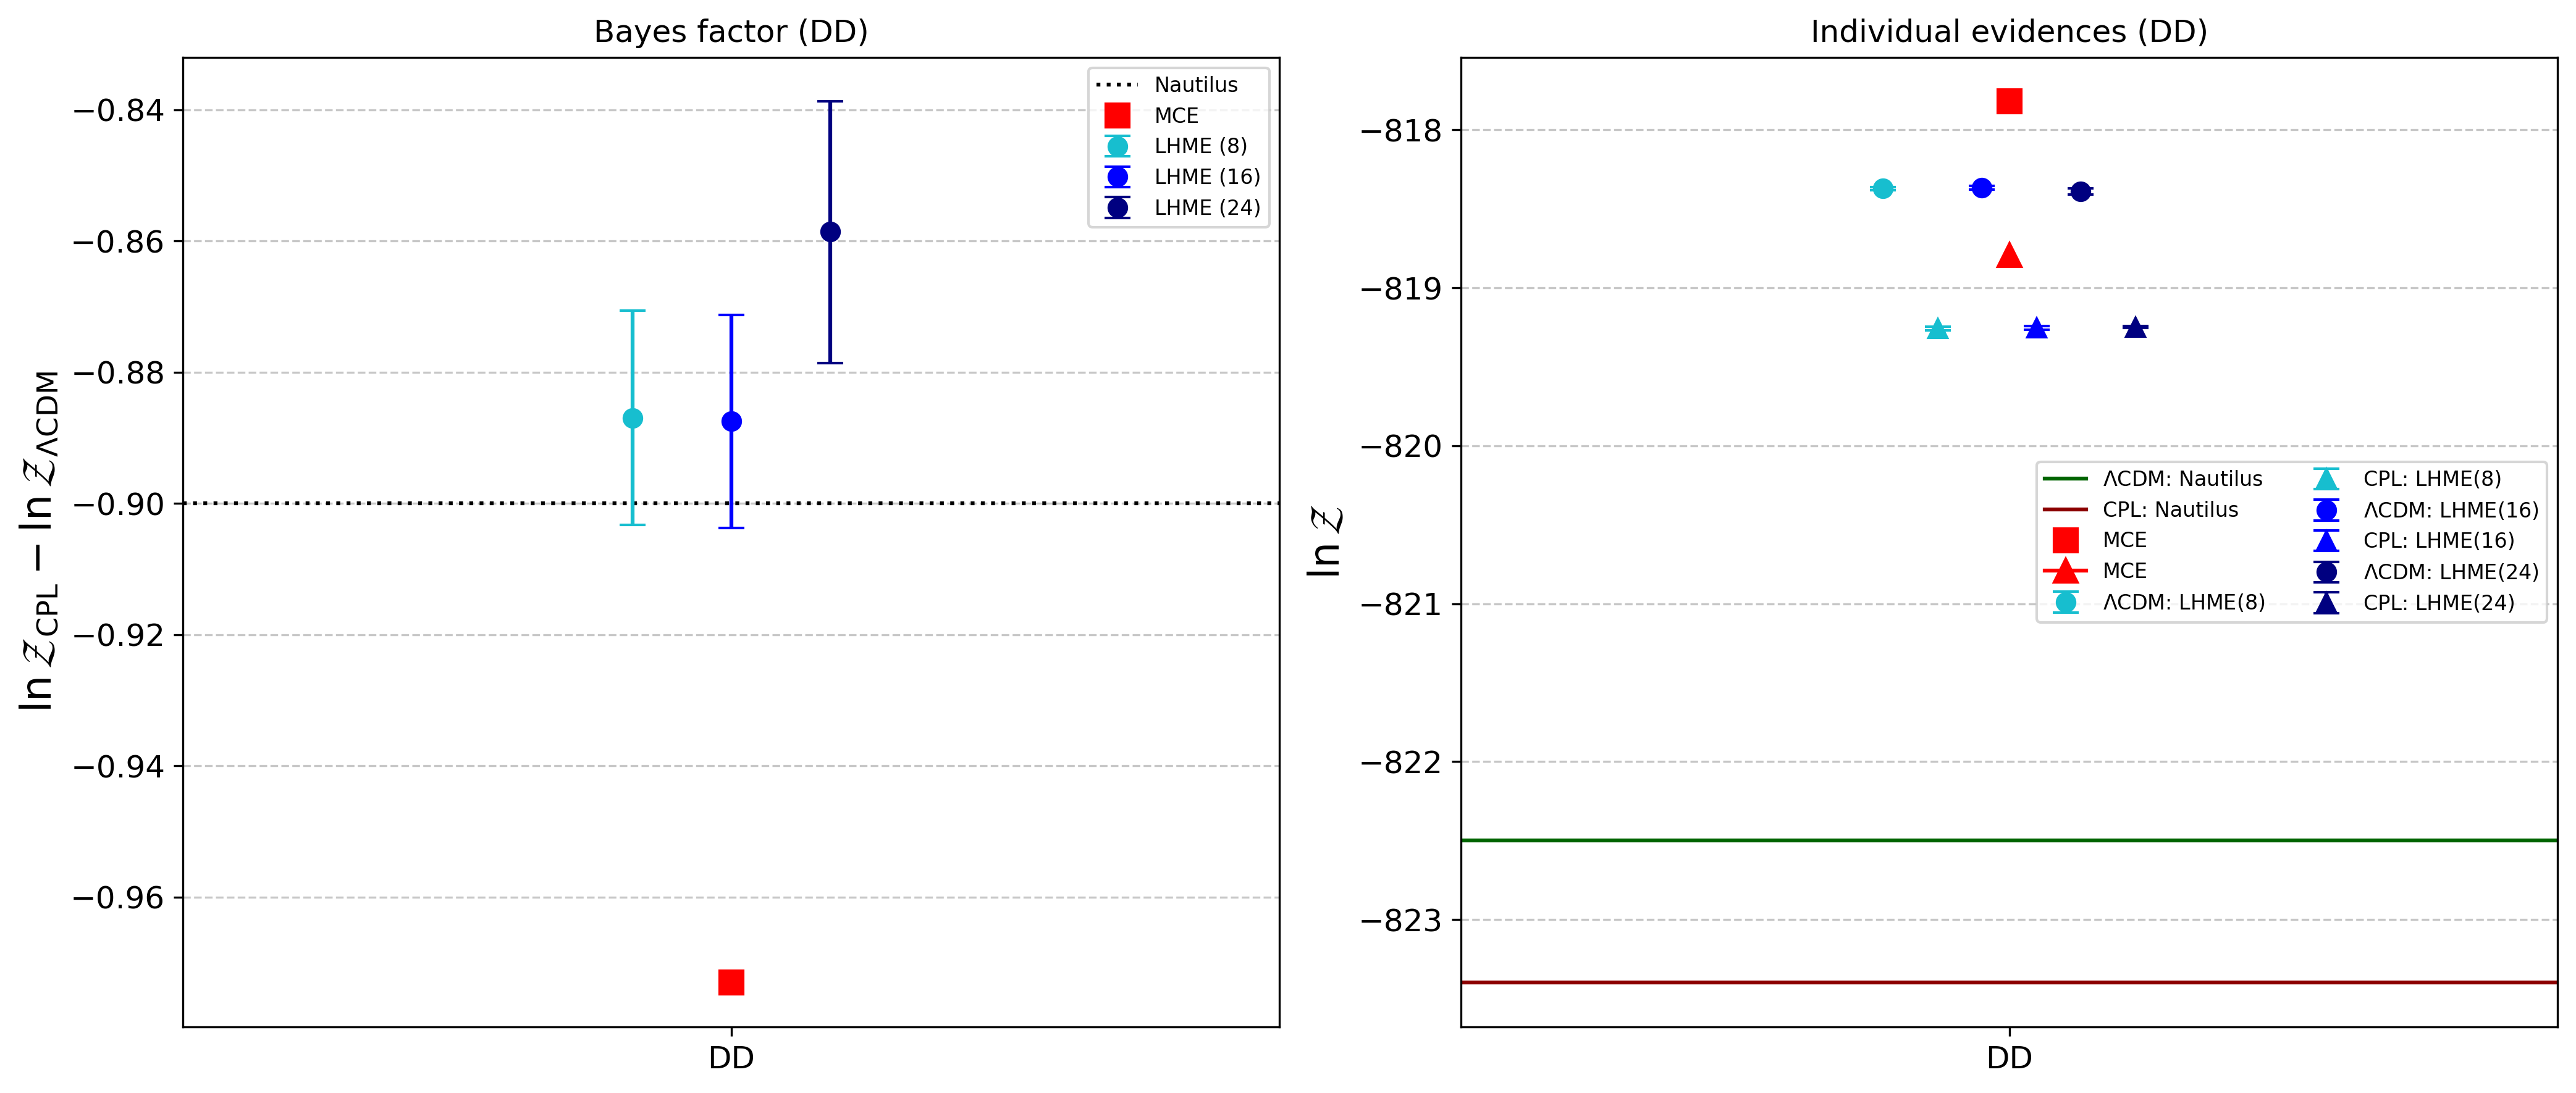

In [8]:
# plotting Bayes factor and individual evidences (DD)
x_labels = ["DD"]
x_pos = np.array([0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Bayes factor ---
ax = axes[0]
ax.axhline(NAUT_DD["bf"], color="black", linestyle=":", label="Nautilus")
ax.plot(x_pos, [mce_dd], "s", color="red", label="MCE", markersize=9)
for bn in block_nums:
    mean = harm_dd_blocks[bn][0]
    lower = harm_dd_blocks[bn][1]
    upper = harm_dd_blocks[bn][2]
    ax.errorbar(
        x_pos + block_offsets[bn],
        [mean],
        yerr=[[lower], [upper]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=f"LHME ({bn})",
        markersize=7,
    )
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}_\mathrm{CPL}-\ln\mathcal{Z}_{\Lambda\mathrm{CDM}}$")
ax.set_title("Bayes factor (DD)")
ax.set_xlim(-1, 1)
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# --- Individual evidences ---
ax = axes[1]
ax.axhline(
    NAUT_DD["lcdm"], color="darkgreen", linestyle="-", label=r"$\Lambda$CDM: Nautilus"
)
ax.axhline(NAUT_DD["cpl"], color="darkred", linestyle="-", label=r"CPL: Nautilus")
for bn in block_nums:
    lcdm_lnZ, (lcdm_lo, lcdm_up) = hmZ_lcdm_dd[bn]
    cpl_lnZ, (cpl_lo, cpl_up) = hmZ_cpl_dd[bn]
    ax.errorbar(
        x_pos + block_offsets[bn] - 0.05,
        [lcdm_lnZ],
        yerr=[[lcdm_lo], [lcdm_up]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=rf"$\Lambda$CDM: LHME({bn})",
        markersize=7,
    )
    ax.errorbar(
        x_pos + block_offsets[bn] + 0.05,
        [cpl_lnZ],
        yerr=[[cpl_lo], [cpl_up]],
        fmt="^",
        color=block_colors[bn],
        capsize=5,
        label=rf"CPL: LHME({bn})",
        markersize=7,
    )
ax.plot(x_pos, mce_dd_lcdm, "s", color="red", label="MCE", markersize=9)  # LCDM
ax.plot(x_pos, mce_dd_cpl, color="red", marker="^", label="MCE", markersize=9)  # CPL
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}$")
ax.set_title("Individual evidences (DD)")
ax.set_xlim(-1, 1)
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("figures/nautilus_DD_evidence.pdf", bbox_inches="tight")
plt.show()

# DD+BAO

In [9]:
## parameters (same as DD)
lcdm_params_ddbao = ["h", "Omega_m"]
cpl_params_ddbao = ["h", "Omega_m", "w0_fld", "wa_fld"]

lcdm_root_ddbao = "../nautilus/lcdm_DD+BAO"
cpl_root_ddbao = "../nautilus/cpl_DD+BAO"

lcdm_ddbao = cosmo_model(lcdm_root_ddbao, block_num=16, nchains=8, burnin=0.3)
cpl_ddbao = cosmo_model(cpl_root_ddbao, block_num=16, nchains=8, burnin=0.3)

lcdm_ddbao.set_sampled_params(lcdm_params_ddbao)
cpl_ddbao.set_sampled_params(cpl_params_ddbao)

print(f"LCDM (DD+BAO) R-1 = {lcdm_ddbao.get_gelman_rubin()}")
print(f"CPL  (DD+BAO) R-1 = {cpl_ddbao.get_gelman_rubin()}")

../nautilus/lcdm_DD+BAO.1.txt
../nautilus/lcdm_DD+BAO.2.txt
../nautilus/lcdm_DD+BAO.3.txt
../nautilus/lcdm_DD+BAO.4.txt
../nautilus/lcdm_DD+BAO.5.txt
../nautilus/lcdm_DD+BAO.6.txt
../nautilus/lcdm_DD+BAO.7.txt
../nautilus/lcdm_DD+BAO.8.txt
Removed 0.3 as burn in
LCDM (DD+BAO) R-1 = 0.003484327223443179
../nautilus/cpl_DD+BAO.1.txt
../nautilus/cpl_DD+BAO.2.txt
../nautilus/cpl_DD+BAO.3.txt
../nautilus/cpl_DD+BAO.4.txt
../nautilus/cpl_DD+BAO.5.txt
../nautilus/cpl_DD+BAO.6.txt
../nautilus/cpl_DD+BAO.7.txt
../nautilus/cpl_DD+BAO.8.txt
Removed 0.3 as burn in
CPL  (DD+BAO) R-1 = 0.0052640820915312095


In [10]:
# train normalising flows
# lcdm_ddbao.train_model(verbose=True, temp=0.8)
# cpl_ddbao.train_model(verbose=True, temp=0.8)

In [11]:
# MCEvidence Bayes factor (DD+BAO)
mce_ddbao_lcdm = lcdm_ddbao.mcevidence
mce_ddbao_cpl = cpl_ddbao.mcevidence
mce_ddbao = lcdm_ddbao.get_MCE_bayes_factor(cpl_ddbao)

INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../nautilus/lcdm_DD+BAO_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.144
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=2
INFO:MCEvidence.py.setup():164      Loading chain from ../nautilus/lcdm_DD+BAO_BE
INFO:MCEvidence.py.load_from_file():666       loading files: ../nautilus/lcdm_DD+BAO_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD+BAO_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD+BAO_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD+BAO_BE.1.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD+BAO_BE.5.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD

RUNNING MCMC EVIDENCE FOR COBAYA
../nautilus/lcdm_DD+BAO.1.txt
../nautilus/lcdm_DD+BAO.2.txt
../nautilus/lcdm_DD+BAO.3.txt
../nautilus/lcdm_DD+BAO.4.txt
../nautilus/lcdm_DD+BAO.5.txt
../nautilus/lcdm_DD+BAO.6.txt
../nautilus/lcdm_DD+BAO.7.txt
../nautilus/lcdm_DD+BAO.8.txt
Removed no burn in
ln(B)[k=1] = -828.0304677685286


RUNNING MCMC EVIDENCE FOR COBAYA
../nautilus/cpl_DD+BAO.1.txt
../nautilus/cpl_DD+BAO.2.txt
../nautilus/cpl_DD+BAO.3.txt
../nautilus/cpl_DD+BAO.4.txt
../nautilus/cpl_DD+BAO.5.txt
../nautilus/cpl_DD+BAO.6.txt
../nautilus/cpl_DD+BAO.7.txt
../nautilus/cpl_DD+BAO.8.txt
Removed no burn in


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../nautilus/cpl_DD+BAO_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=1.872
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=4
INFO:MCEvidence.py.setup():164      Loading chain from ../nautilus/cpl_DD+BAO_BE
INFO:MCEvidence.py.load_from_file():666       loading files: ../nautilus/cpl_DD+BAO_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.1.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.

ln(B)[k=1] = -829.4735184800795




In [12]:
# LHME Bayes factor (DD+BAO, block_num=16)
lcdm_ddbao.load_model(temp=0.7)
cpl_ddbao.load_model(temp=0.7)
harm_ddbao = lcdm_ddbao.get_LHME_bayes_factor(cpl_ddbao)

print("LCDM (DD+BAO) block_num=16")
lcdm_ddbao.diagnose_flow()
lcdm_ddbao.diagnose_evidence()
print("CPL (DD+BAO) block_num=16")
cpl_ddbao.diagnose_flow()
cpl_ddbao.diagnose_evidence()

LCDM (DD+BAO) block_num=16
=== Flow Diagnostics ===
Flow in posterior box (q=0.005): 0.997 (want ~1; low => flow leaks outside posterior)
Val - Train NLL gap:                  +0.212 (large positive => overfitting)
=== Evidence Diagnostics ===
  T=0.70: lnZ = -828.4393 +/- 0.0146  (rel err of err: 0.35)
  T=0.75: lnZ = -828.4413 +/- 0.0120  (rel err of err: 0.36)
  T=0.80: lnZ = -828.4431 +/- 0.0097  (rel err of err: 0.36)
  T=0.85: lnZ = -828.4448 +/- 0.0078  (rel err of err: 0.33)
Spread (max-min):      0.0054
Typical formal error:  0.0110
Spread / error:        0.49 (<= ~2 consistent; 2-3 marginal; >> 3 likely leaks; monotonic trend in lnZ(T) above = small bias, random scatter = MC noise)
Rel err of err per T should be <= ~0.3; >> 1 => error bar itself unreliable
CPL (DD+BAO) block_num=16
=== Flow Diagnostics ===
Flow in posterior box (q=0.005): 0.994 (want ~1; low => flow leaks outside posterior)
Val - Train NLL gap:                  +0.165 (large positive => overfitting)
=== Evide

{'lnZ_by_temp': {0.7: np.float32(-829.7555),
  0.75: np.float32(-829.7581),
  0.8: np.float32(-829.7607),
  0.85: np.float32(-829.7631)},
 'err_by_temp': {0.7: np.float32(0.022210076),
  0.75: np.float32(0.017849643),
  0.8: np.float32(0.01370945),
  0.85: np.float32(0.010006523)},
 'var_rel_by_temp': {0.7: 0.39294642210006714,
  0.75: 0.3881314694881439,
  0.8: 0.3746318221092224,
  0.85: 0.3485139012336731},
 'spread': 0.00762939453125,
 'typical_err': 0.015943923965096474,
 'ratio': 0.4785142320015972}

In [ ]:
# block_num variants for harmonic (DD+BAO)
harm_ddbao_blocks = {16: harm_ddbao}
hmZ_lcdm_ddbao = {16: lcdm_ddbao.get_hm_evidence()}
hmZ_cpl_ddbao = {16: cpl_ddbao.get_hm_evidence()}

for bn in [8, 24]:
    a = make_and_train(
        lcdm_root_ddbao, lcdm_params_ddbao, burnin=0.3, block_num=bn, temp=0.7
    )
    b = make_and_train(
        cpl_root_ddbao, cpl_params_ddbao, burnin=0.3, block_num=bn, temp=0.7
    )
    harm_ddbao_blocks[bn] = a.get_LHME_bayes_factor(b)
    hmZ_lcdm_ddbao[bn] = a.get_hm_evidence()
    hmZ_cpl_ddbao[bn] = b.get_hm_evidence()
    print(f"LCDM (DD+BAO) block_num={bn}")
    a.diagnose_flow()
    a.diagnose_evidence()
    print(f"CPL (DD+BAO) block_num={bn}")
    b.diagnose_flow()
    b.diagnose_evidence()

LCDM (DD+BAO) block_num=8
=== Flow Diagnostics ===
Flow in posterior box (q=0.005): 0.996 (want ~1; low => flow leaks outside posterior)
Val - Train NLL gap:                  +0.084 (large positive => overfitting)
=== Evidence Diagnostics ===
  T=0.70: lnZ = -828.4467 +/- 0.0073  (rel err of err: 0.50)
  T=0.75: lnZ = -828.4483 +/- 0.0061  (rel err of err: 0.49)
  T=0.80: lnZ = -828.4498 +/- 0.0048  (rel err of err: 0.48)
  T=0.85: lnZ = -828.4512 +/- 0.0035  (rel err of err: 0.48)
Spread (max-min):      0.0045
Typical formal error:  0.0054
Spread / error:        0.83 (<= ~2 consistent; 2-3 marginal; >> 3 likely leaks; monotonic trend in lnZ(T) above = small bias, random scatter = MC noise)
Rel err of err per T should be <= ~0.3; >> 1 => error bar itself unreliable
CPL (DD+BAO) block_num=8
=== Flow Diagnostics ===
Flow in posterior box (q=0.005): 0.994 (want ~1; low => flow leaks outside posterior)
Val - Train NLL gap:                  +0.186 (large positive => overfitting)
=== Evidenc

INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode


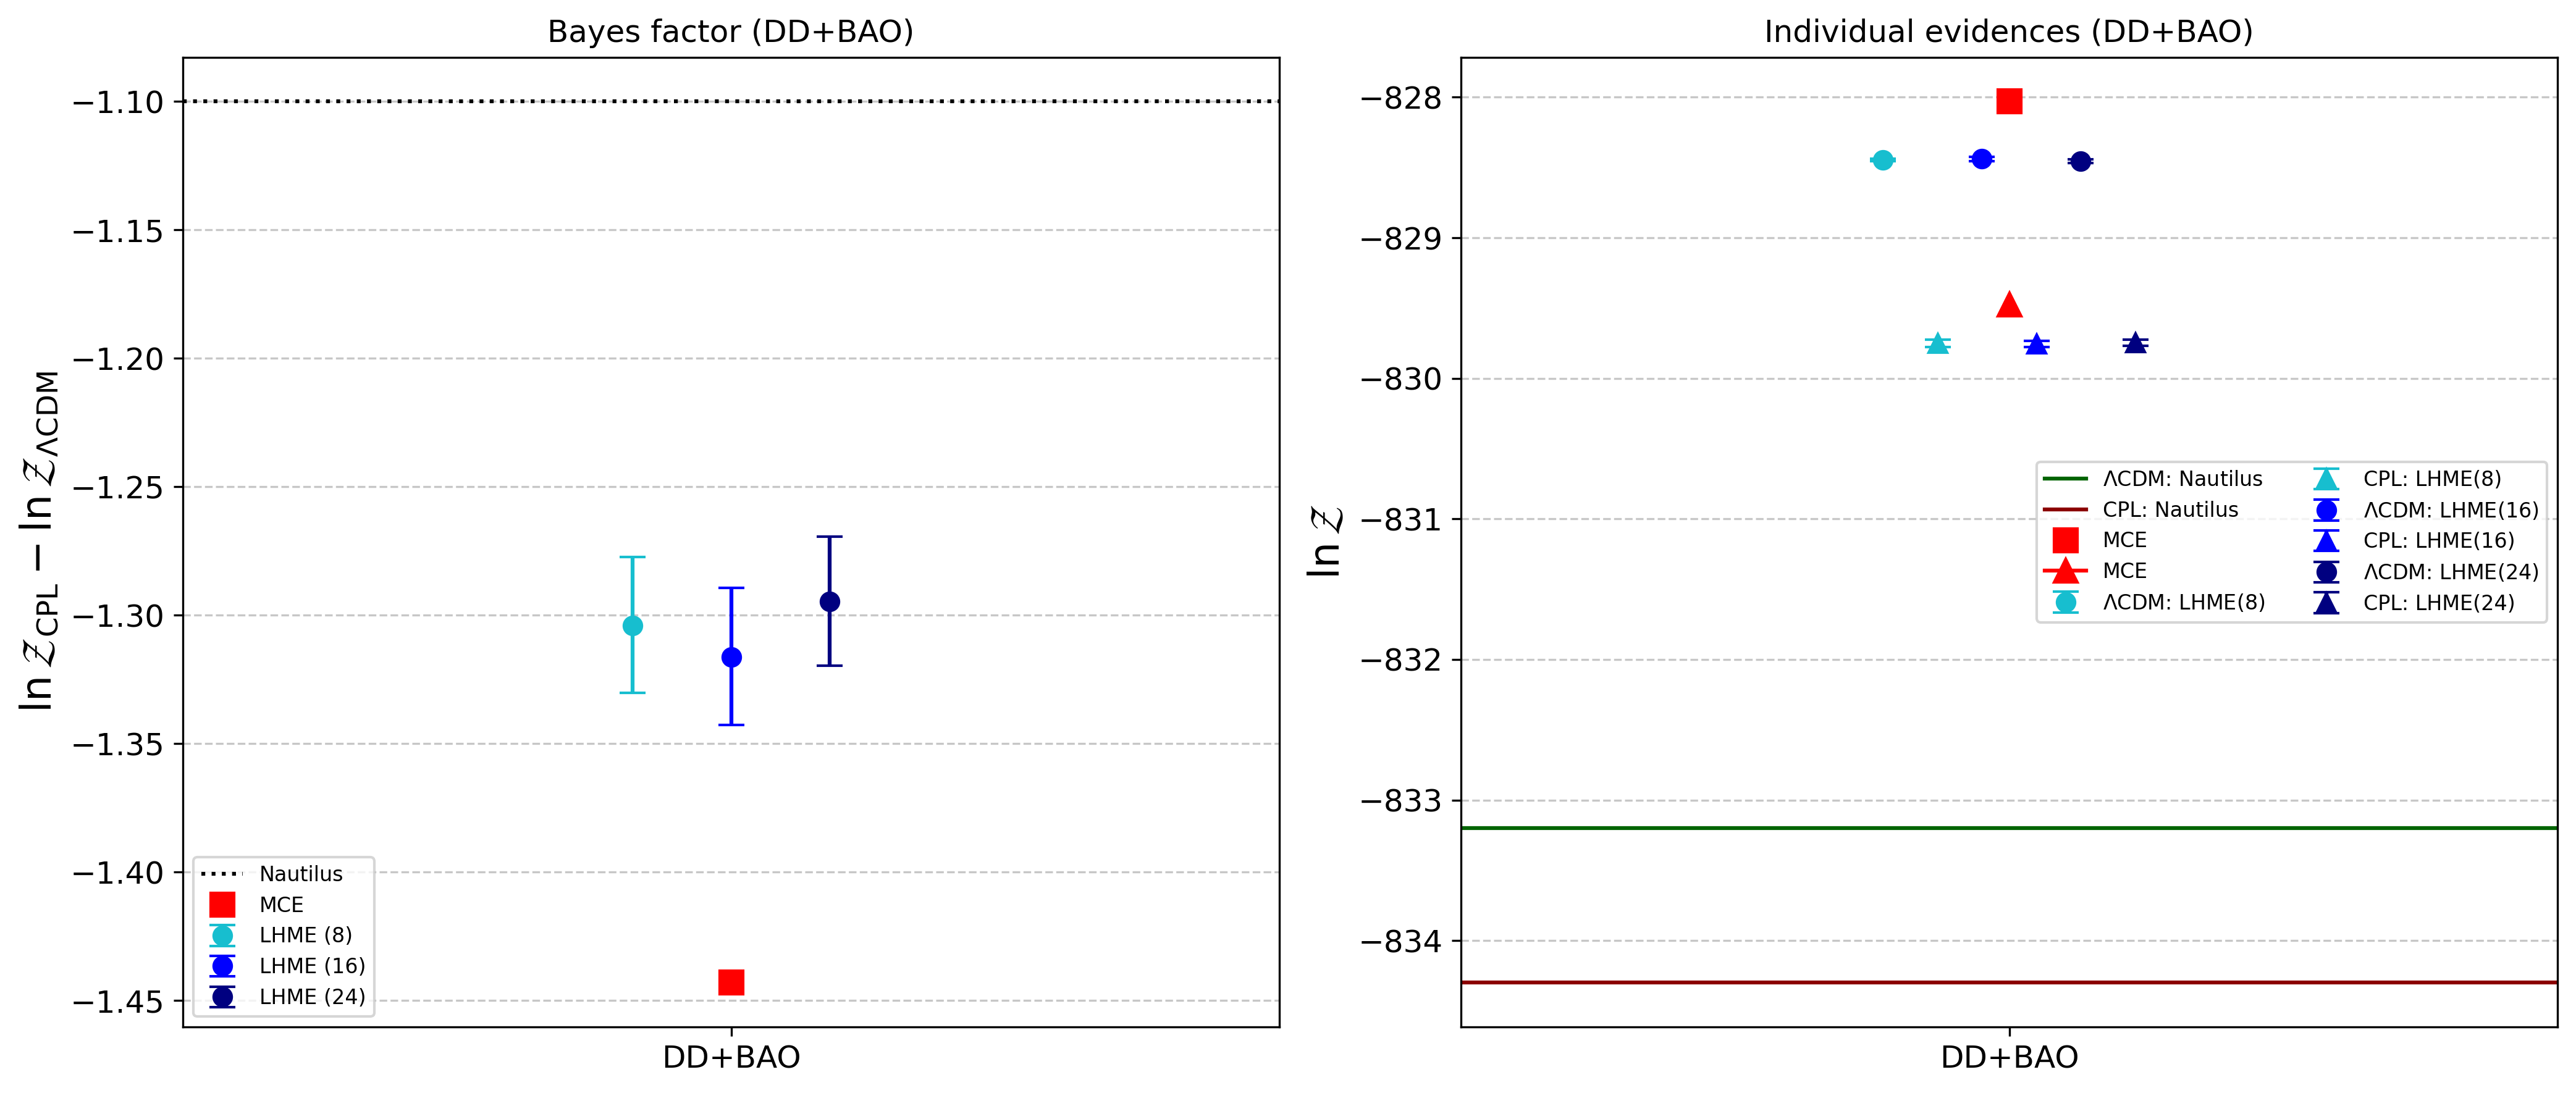

In [14]:
# plotting Bayes factor and individual evidences (DD+BAO)
x_labels = ["DD+BAO"]
x_pos = np.array([0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Bayes factor ---
ax = axes[0]
ax.axhline(NAUT_DDBAO["bf"], color="black", linestyle=":", label="Nautilus")
ax.plot(x_pos, [mce_ddbao], "s", color="red", label="MCE", markersize=9)
for bn in block_nums:
    mean = harm_ddbao_blocks[bn][0]
    lower = harm_ddbao_blocks[bn][1]
    upper = harm_ddbao_blocks[bn][2]
    ax.errorbar(
        x_pos + block_offsets[bn],
        [mean],
        yerr=[[lower], [upper]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=f"LHME ({bn})",
        markersize=7,
    )
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}_\mathrm{CPL}-\ln\mathcal{Z}_{\Lambda\mathrm{CDM}}$")
ax.set_title("Bayes factor (DD+BAO)")
ax.set_xlim(-1, 1)
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# --- Individual evidences ---
ax = axes[1]
ax.axhline(
    NAUT_DDBAO["lcdm"],
    color="darkgreen",
    linestyle="-",
    label=r"$\Lambda$CDM: Nautilus",
)
ax.axhline(NAUT_DDBAO["cpl"], color="darkred", linestyle="-", label=r"CPL: Nautilus")
for bn in block_nums:
    lcdm_lnZ, (lcdm_lo, lcdm_up) = hmZ_lcdm_ddbao[bn]
    cpl_lnZ, (cpl_lo, cpl_up) = hmZ_cpl_ddbao[bn]
    ax.errorbar(
        x_pos + block_offsets[bn] - 0.05,
        [lcdm_lnZ],
        yerr=[[lcdm_lo], [lcdm_up]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=rf"$\Lambda$CDM: LHME({bn})",
        markersize=7,
    )
    ax.errorbar(
        x_pos + block_offsets[bn] + 0.05,
        [cpl_lnZ],
        yerr=[[cpl_lo], [cpl_up]],
        fmt="^",
        color=block_colors[bn],
        capsize=5,
        label=rf"CPL: LHME({bn})",
        markersize=7,
    )
ax.plot(x_pos, mce_ddbao_lcdm, "s", color="red", label="MCE", markersize=9)  # LCDM
ax.plot(x_pos, mce_ddbao_cpl, color="red", marker="^", label="MCE", markersize=9)  # CPL
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}$")
ax.set_title("Individual evidences (DD+BAO)")
ax.set_xlim(-1, 1)
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("figures/nautilus_DD+BAO_evidence.pdf", bbox_inches="tight")
plt.show()

# Numerical summary

Printing all evidence and Bayes-factor values produced above so it is clear which number came from which estimator.

In [15]:
def fmt_lnZ(hm_res):
    lnZ, (lo, up) = hm_res
    return f"{lnZ:+.3f} (+{up:.3f} / -{lo:.3f})"


def fmt_bf(bf_tuple):
    mean, lo, up = bf_tuple
    return f"{mean:+.3f} (+{up:.3f} / -{lo:.3f})"


def print_dataset(name, naut, mce_bf, harm_blocks, hmZ_lcdm, hmZ_cpl):
    print(f"=== {name} ===")
    print("  ln Z (LCDM):")
    print(f"    Nautilus     : {naut['lcdm']:+.3f}")
    for bn in block_nums:
        print(f"    LHME bn={bn:>2}  : {fmt_lnZ(hmZ_lcdm[bn])}")
    print("  ln Z (CPL):")
    print(f"    Nautilus     : {naut['cpl']:+.3f}")
    for bn in block_nums:
        print(f"    LHME bn={bn:>2}  : {fmt_lnZ(hmZ_cpl[bn])}")
    print("  Bayes factor  ln Z_CPL - ln Z_LCDM:")
    print(f"    Nautilus     : {naut['bf']:+.3f}")
    print(f"    MCEvidence   : {mce_bf:+.3f}")
    for bn in block_nums:
        print(f"    LHME bn={bn:>2}  : {fmt_bf(harm_blocks[bn])}")
    print()


print_dataset("DD", NAUT_DD, mce_dd, harm_dd_blocks, hmZ_lcdm_dd, hmZ_cpl_dd)
print_dataset(
    "DD+BAO", NAUT_DDBAO, mce_ddbao, harm_ddbao_blocks, hmZ_lcdm_ddbao, hmZ_cpl_ddbao
)

=== DD ===
  ln Z (LCDM):
    Nautilus     : -822.500
    LHME bn= 8  : -818.371 (+0.010 / -0.010)
    LHME bn=16  : -818.366 (+0.013 / -0.012)
    LHME bn=24  : -818.390 (+0.019 / -0.018)
  ln Z (CPL):
    Nautilus     : -823.400
    LHME bn= 8  : -819.258 (+0.013 / -0.013)
    LHME bn=16  : -819.253 (+0.010 / -0.010)
    LHME bn=24  : -819.248 (+0.007 / -0.007)
  Bayes factor  ln Z_CPL - ln Z_LCDM:
    Nautilus     : -0.900
    MCEvidence   : -0.973
    LHME bn= 8  : -0.887 (+0.016 / -0.016)
    LHME bn=16  : -0.887 (+0.016 / -0.016)
    LHME bn=24  : -0.859 (+0.020 / -0.020)

=== DD+BAO ===
  ln Z (LCDM):
    Nautilus     : -833.200
    LHME bn= 8  : -828.447 (+0.007 / -0.007)
    LHME bn=16  : -828.439 (+0.015 / -0.015)
    LHME bn=24  : -828.453 (+0.014 / -0.013)
  ln Z (CPL):
    Nautilus     : -834.300
    LHME bn= 8  : -829.751 (+0.026 / -0.025)
    LHME bn=16  : -829.755 (+0.022 / -0.022)
    LHME bn=24  : -829.748 (+0.021 / -0.021)
  Bayes factor  ln Z_CPL - ln Z_LCDM:
    Na